# Technical Analysis of Historical Stock Data

## 1. Data Loading and Inspection

In [2]:
import pandas as pd

df = pd.read_csv('../data/yfinance/AAPL.csv')

df.head(20)

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800
5,2009-01-09,2.716589,2.800564,2.703393,2.795466,546845600
6,2009-01-12,2.659007,2.728886,2.625717,2.712990,617716400
7,2009-01-13,2.630514,2.691395,2.589726,2.646409,798397600
8,2009-01-14,2.559135,2.616717,2.540840,2.586427,1021664000
9,2009-01-15,2.500652,2.522846,2.400782,2.416377,1831634000


In [3]:
df.shape

(3774, 6)

In [4]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


In [6]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## 2. Data Cleaning and Missing Value Analysis

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


In [9]:
df = df.sort_values('Date')

In [10]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## 3. Technical Indicators (Simple Moving Average / SMA)

In [11]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()

## 4. Visualizations

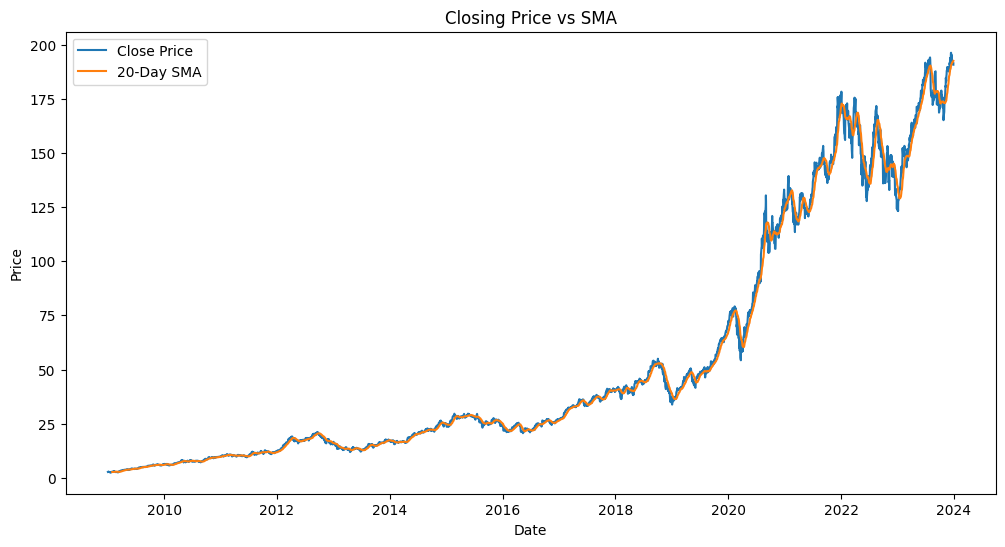

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['SMA_20'], label='20-Day SMA')

plt.title('Closing Price vs SMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()

In [13]:
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

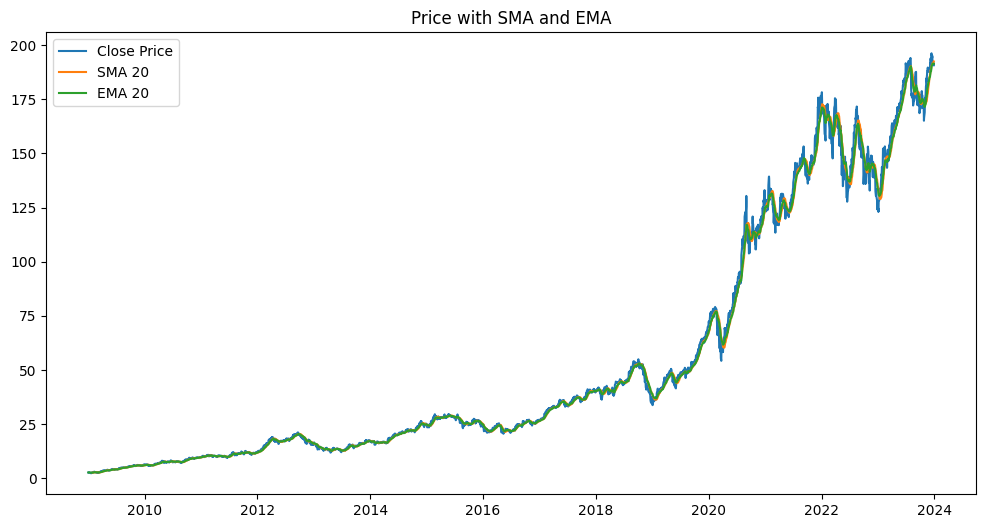

In [14]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['EMA_20'], label='EMA 20')

plt.legend()
plt.title('Price with SMA and EMA')

plt.show()

COMPUTING RSI

RSI helps detect:

overbought conditions
oversold conditions
momentum strength

In [15]:
import talib

df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

df[['Date', 'Close', 'RSI']].tail()

,Date,Close,RSI
3769,2023-12-22,191.788757,54.672784
3770,2023-12-26,191.243912,53.090049
3771,2023-12-27,191.342972,53.354446
3772,2023-12-28,191.768951,54.540999
3773,2023-12-29,190.728775,51.121347


The Relative Strength Index (RSI) was computed using a 14-day window to evaluate momentum and potential overbought or oversold conditions in the stock price. RSI values above 70 may indicate that the asset is overbought, while values below 30 may signal oversold conditions and potential reversal opportunities. From the result above we can conclude that the conditions were relatively medium.

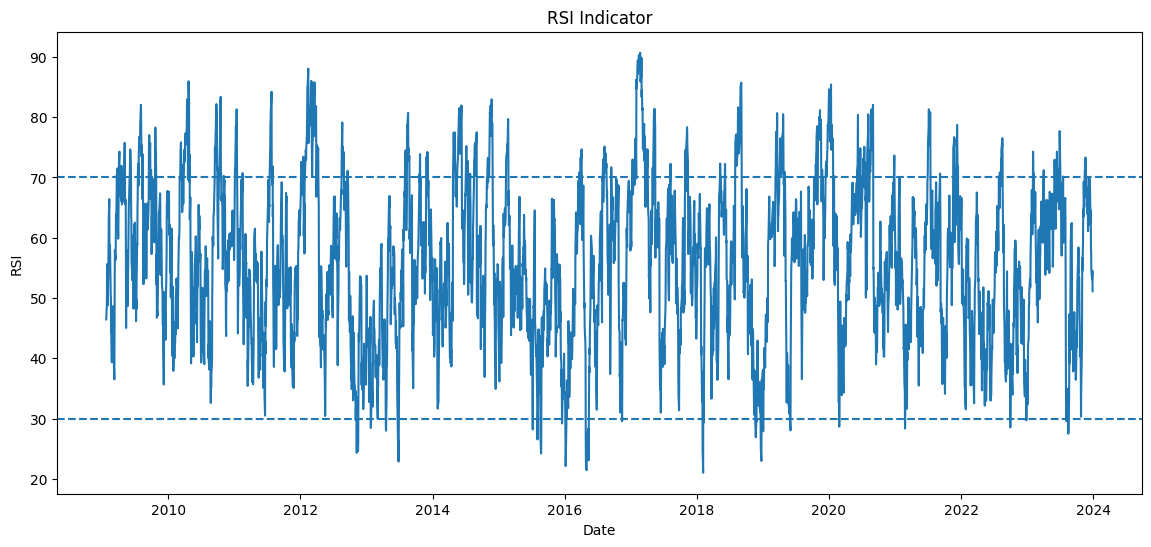

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['RSI'])

plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')

plt.title('RSI Indicator')
plt.xlabel('Date')
plt.ylabel('RSI')

plt.show()

What the above graph shows
- Above 70: Possible market overheating
- Below 30: Possible undervaluation or recovery opportunity
- Mid-range (~50): Neutral momentum.

The RSI visualization showed fluctuating momentum patterns throughout the observed trading period. Several intervals stayed within the average range (30 to 70) although sometimes, it can be infered that there is an overbought threshold passing by the intervals (above 70)

In [17]:
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

df[['MACD', 'MACD_signal']].tail()

,MACD,MACD_signal
3769,2.633141,3.235256
3770,2.304751,3.049155
3771,2.029104,2.845145
3772,1.823998,2.640915
3773,1.559539,2.424640


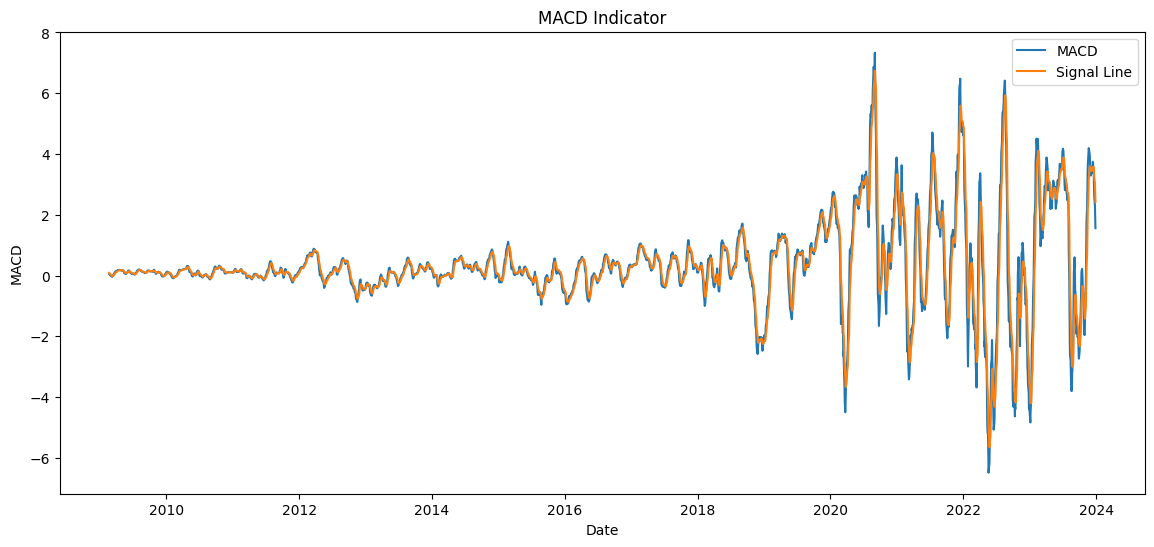

In [18]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['MACD'], label='MACD')
plt.plot(df['Date'], df['MACD_signal'], label='Signal Line')

plt.title('MACD Indicator')
plt.xlabel('Date')
plt.ylabel('MACD')

plt.legend()

plt.show()

The MACD indicator was used to analyze trend momentum and identify possible trend reversals. Crossovers between the MACD line and the signal line highlighted potential bullish and bearish momentum shifts. The visualization demonstrated periods where market momentum accelerated or weakened over time.

In [19]:
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)
df['EMA_50'] = talib.EMA(df['Close'], timeperiod=50)

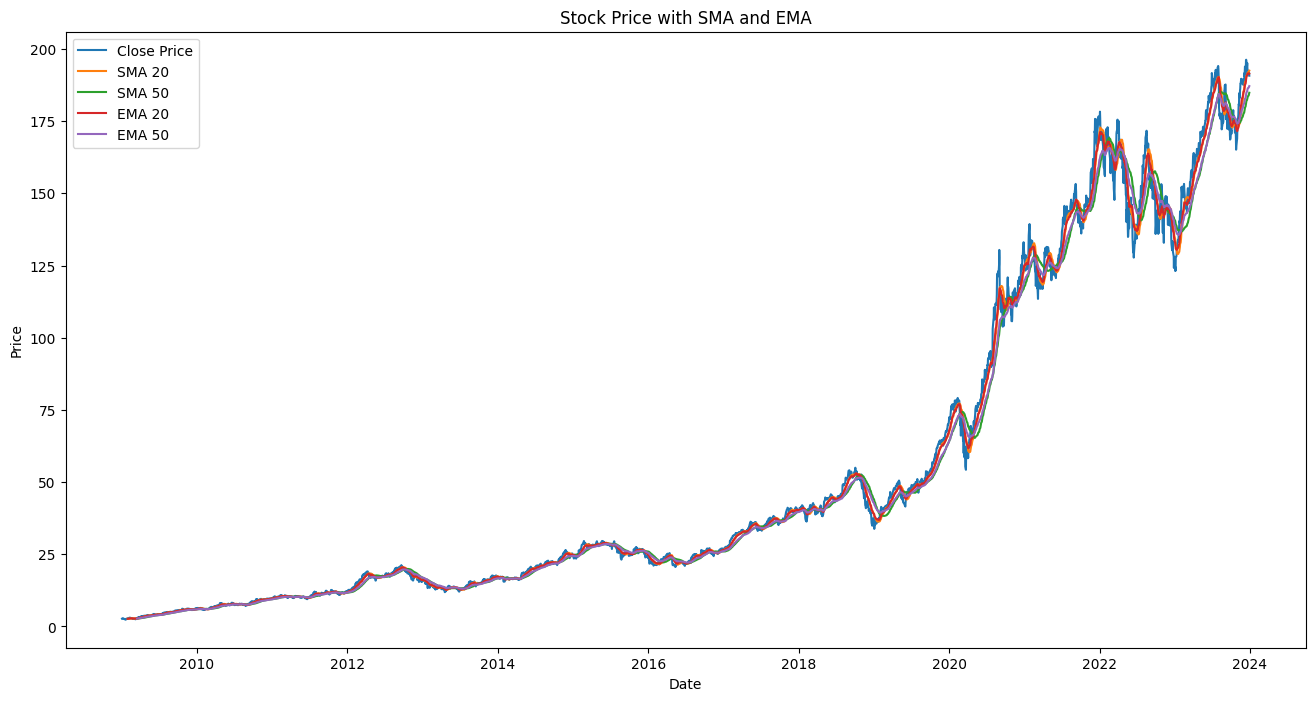

In [20]:
plt.figure(figsize=(16,8))

plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['SMA_50'], label='SMA 50')

plt.plot(df['Date'], df['EMA_20'], label='EMA 20')
plt.plot(df['Date'], df['EMA_50'], label='EMA 50')

plt.title('Stock Price with SMA and EMA')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.show()

In the above price visualization graph, Multiple moving average windows were analyzed to capture both short-term and long-term market trends. The EMA indicators reacted more quickly to recent price fluctuations, while the SMA indicators provided smoother long-term trend representations. Crossovers between short and long moving averages suggested potential momentum and trend reversals.

## Conclusion

This analysis explored historical stock price behavior using technical indicators and financial metrics. SMA and EMA indicators revealed long-term and short-term trend behavior, while RSI and MACD highlighted momentum changes and possible reversal periods. The dataset showed strong temporal consistency with no missing values and correctly formatted numerical columns. These findings establish a foundation for the next phase of the project, where financial news sentiment will be correlated with stock market behavior.